<a href="https://colab.research.google.com/github/asnavirmedia01/fraud-detection-model/blob/main/SEMINAR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
file_path = '/content/drive/MyDrive/FRAUD DETECTION PROJECT/Synthetic_Fraud_Dataset.xlsx'
df = pd.read_excel(file_path)
print(df.head())

  Transaction_ID  Transaction_Amount  Transaction_Hour  Location_Change  \
0       TRX00001              192170                 3                0   
1       TRX00002               71832                 0                0   
2       TRX00003               46020                 7                0   
3       TRX00004              164360                13                0   
4       TRX00005               30083                 8                0   

   Device_Mismatch  Transaction_Velocity  Account_Age_Days  \
0                1                     2              2772   
1                0                     5                75   
2                0                     2              2383   
3                0                     3              2465   
4                0                     5              2105   

   AvgTransaction_Last30Days  Amount_To_Average_Ratio  User_Income_Estimate  \
0                      43046                     4.46              293181.0   
1                 

In [ ]:
df.head()

,Transaction_ID,Transaction_Amount,Transaction_Hour,Location_Change,Device_Mismatch,Transaction_Velocity,Account_Age_Days,AvgTransaction_Last30Days,Amount_To_Average_Ratio,User_Income_Estimate,Device_OS,Customer_Marital_Status,Last_Manual_Review_Note,RESULT
0,TRX00001,192170,3,0,1,2,2772,43046,4.46,293181.0,Android,Married,NaN,0
1,TRX00002,71832,0,0,0,5,75,77725,0.92,178131.0,Android,NaN,NaN,1
2,TRX00003,46020,7,0,0,2,2383,66477,0.69,50244.0,iOS,Widowed,NaN,0
3,TRX00004,164360,13,0,0,3,2465,39678,4.14,257358.0,iOS,Divorced,Suspicious IP,0
4,TRX00005,30083,8,0,0,5,2105,15236,1.97,85568.0,Android,Divorced,NaN,0


In [ ]:
df.info()
df.describe()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Transaction_ID             10000 non-null  object 
 1   Transaction_Amount         10000 non-null  int64  
 2   Transaction_Hour           10000 non-null  int64  
 3   Location_Change            10000 non-null  int64  
 4   Device_Mismatch            10000 non-null  int64  
 5   Transaction_Velocity       10000 non-null  int64  
 6   Account_Age_Days           10000 non-null  int64  
 7   AvgTransaction_Last30Days  10000 non-null  int64  
 8   Amount_To_Average_Ratio    10000 non-null  float64
 9   User_Income_Estimate       8554 non-null   float64
 10  Device_OS                  8987 non-null   object 
 11  Customer_Marital_Status    7953 non-null   object 
 12  Last_Manual_Review_Note    3007 non-null   object 
 13  RESULT                     10000 non-null  int6

(10000, 14)

#IMPORTING OF LIBRARIES

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.utils import resample
import joblib
import zipfile

#EXPLORATORY DATA ANALYSIS

In [ ]:
df.isnull().sum()

,0
Transaction_ID,0
Transaction_Amount,0
Transaction_Hour,0
Location_Change,0
Device_Mismatch,0
Transaction_Velocity,0
Account_Age_Days,0
AvgTransaction_Last30Days,0
Amount_To_Average_Ratio,0
User_Income_Estimate,1446


Value counts for 'RESULT' column:
RESULT
0    7587
1    2413
Name: count, dtype: int64

In the 'RESULT' column: 
 - 0 represents Legit Transactions
 - 1 represents Fraudulent Transactions


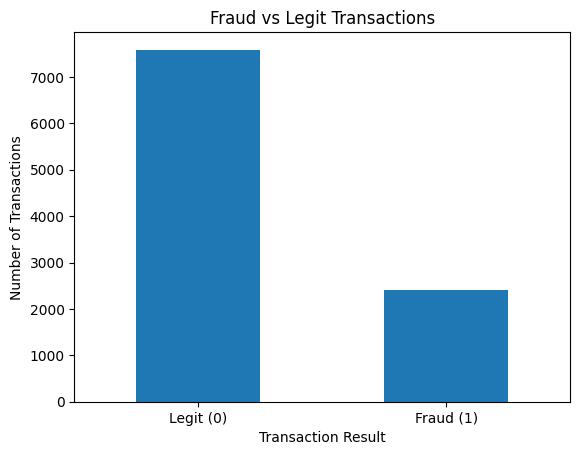

In [ ]:
result_counts = df['RESULT'].value_counts()
print("Value counts for 'RESULT' column:")
print(result_counts)
print("\nIn the 'RESULT' column: ")
print(" - 0 represents Legit Transactions")
print(" - 1 represents Fraudulent Transactions")
# 0 represents Legit Transactions
# 1 represents Fraudulent Transactions

plt.figure()
result_counts.plot(kind='bar')
plt.title("Fraud vs Legit Transactions")
plt.xlabel("Transaction Result")
plt.ylabel("Number of Transactions")
plt.xticks(ticks=[0, 1], labels=['Legit (0)', 'Fraud (1)'], rotation=0)
plt.show()

In [ ]:
missing_percentage = df['Last_Manual_Review_Note'].isnull().mean()*100
print("Missing Percentage:", missing_percentage)

Missing Percentage: 69.93


In [ ]:
missing_percentages = df.isnull().mean() * 100
print("Columns with missing values and their percentages:")
print(missing_percentages[missing_percentages > 0].sort_values(ascending=False))

# Identify columns with a very high percentage of missing values (e.g., > 50%)
high_missing_cols = missing_percentages[missing_percentages > 50].index.tolist()
print(f"\nColumns with more than 50% missing values: {high_missing_cols}")

# Also consider columns that might be unique identifiers (like Transaction_ID)
# which are often not useful for direct modeling.
if 'Transaction_ID' in df.columns:
    print("\n'Transaction_ID' is an identifier and typically not useful for modeling.")




Columns with missing values and their percentages:
Last_Manual_Review_Note    69.93
Customer_Marital_Status    20.47
User_Income_Estimate       14.46
Device_OS                  10.13
dtype: float64

Columns with more than 50% missing values: ['Last_Manual_Review_Note']

'Transaction_ID' is an identifier and typically not useful for modeling.


In [ ]:
df = df.drop(columns=['Transaction_ID','Last_Manual_Review_Note'])

In [ ]:
df

,Transaction_Amount,Transaction_Hour,Location_Change,Device_Mismatch,Transaction_Velocity,Account_Age_Days,AvgTransaction_Last30Days,Amount_To_Average_Ratio,User_Income_Estimate,Device_OS,Customer_Marital_Status,RESULT
0,192170,3,0,1,2,2772,43046,4.46,293181.0,Android,Married,0
1,71832,0,0,0,5,75,77725,0.92,178131.0,Android,NaN,1
2,46020,7,0,0,2,2383,66477,0.69,50244.0,iOS,Widowed,0
3,164360,13,0,0,3,2465,39678,4.14,257358.0,iOS,Divorced,0
4,30083,8,0,0,5,2105,15236,1.97,85568.0,Android,Divorced,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,197569,1,0,1,10,25,94151,2.10,288221.0,Android,Married,1
9996,278629,3,0,0,7,76,95538,2.92,NaN,Windows,Married,1
9997,424090,2,1,1,6,61,7326,57.88,94751.0,Windows,Married,1
9998,97015,0,1,0,2,1985,61143,1.59,NaN,Android,NaN,0


In [ ]:
for col in ['Device_OS', 'Customer_Marital_Status']:
    if df[col].isnull().any():
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)



/tmp/ipykernel_1215/1205807496.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(mode_val, inplace=True)


In [ ]:
print("Missing values after imputation:")
print(df.isnull().sum())

Missing values after imputation:
Transaction_Amount              0
Transaction_Hour                0
Location_Change                 0
Device_Mismatch                 0
Transaction_Velocity            0
Account_Age_Days                0
AvgTransaction_Last30Days       0
Amount_To_Average_Ratio         0
User_Income_Estimate         1446
Device_OS                       0
Customer_Marital_Status         0
RESULT                          0
dtype: int64


In [ ]:
le = LabelEncoder()

categorical_cols = ['Device_OS','Customer_Marital_Status']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

In [ ]:
df_encoded = df.copy()
df_encoded.to_csv('df_encoded.csv', index=False)
print("Encoded dataset saved as 'df_encoded.csv'")


Encoded dataset saved as 'df_encoded.csv'


In [ ]:
df_encoded.head()

,Transaction_Amount,Transaction_Hour,Location_Change,Device_Mismatch,Transaction_Velocity,Account_Age_Days,AvgTransaction_Last30Days,Amount_To_Average_Ratio,User_Income_Estimate,Device_OS,Customer_Marital_Status,RESULT
0,192170,3,0,1,2,2772,43046,4.46,293181.0,0,1,0
1,71832,0,0,0,5,75,77725,0.92,178131.0,0,3,1
2,46020,7,0,0,2,2383,66477,0.69,50244.0,3,3,0
3,164360,13,0,0,3,2465,39678,4.14,257358.0,3,0,0
4,30083,8,0,0,5,2105,15236,1.97,85568.0,0,0,0


In [ ]:
df['High_Risk_Hour'] = df['Transaction_Hour'].apply(lambda x: 1 if x < 6 else 0)

In [ ]:
df

,Transaction_Amount,Transaction_Hour,Location_Change,Device_Mismatch,Transaction_Velocity,Account_Age_Days,AvgTransaction_Last30Days,Amount_To_Average_Ratio,User_Income_Estimate,Device_OS,Customer_Marital_Status,RESULT,High_Risk_Hour
0,192170,3,0,1,2,2772,43046,4.46,293181.0,0,1,0,1
1,71832,0,0,0,5,75,77725,0.92,178131.0,0,3,1,1
2,46020,7,0,0,2,2383,66477,0.69,50244.0,3,3,0,0
3,164360,13,0,0,3,2465,39678,4.14,257358.0,3,0,0,0
4,30083,8,0,0,5,2105,15236,1.97,85568.0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,197569,1,0,1,10,25,94151,2.10,288221.0,0,1,1,1
9996,278629,3,0,0,7,76,95538,2.92,NaN,2,1,1,1
9997,424090,2,1,1,6,61,7326,57.88,94751.0,2,1,1,1
9998,97015,0,1,0,2,1985,61143,1.59,NaN,0,3,0,1


In [ ]:
X = df.drop('RESULT', axis=1)
y = df['RESULT']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
y_train.value_counts()

,count
RESULT,
0,6070
1,1930


#UNDERSAMPLING

In [ ]:
train_data = pd.concat([X_train, y_train], axis=1)

fraud = train_data[train_data.RESULT == 1]
non_fraud = train_data[train_data.RESULT == 0]

non_fraud_downsampled = resample(
    non_fraud,
    replace=False,
    n_samples=len(fraud)*2,
    random_state=42
)

balanced_train = pd.concat([fraud, non_fraud_downsampled])

In [ ]:
X_train_balanced = balanced_train.drop('RESULT', axis=1)
y_train_balanced = balanced_train['RESULT']

In [ ]:
print("Value counts for balanced training data (y_train_balanced):")
print(y_train_balanced.value_counts())

Value counts for balanced training data (y_train_balanced):
RESULT
0    3860
1    1930
Name: count, dtype: int64


In [ ]:
scaler = StandardScaler()

# Ensure X_train_balanced is a DataFrame before imputation (as it might have been converted to array in previous failed run)
X_train_balanced = balanced_train.drop('RESULT', axis=1)

# Impute missing values in 'User_Income_Estimate' before scaling
X_train_balanced['User_Income_Estimate'].fillna(X_train_balanced['User_Income_Estimate'].mean(), inplace=True)
X_test['User_Income_Estimate'].fillna(X_test['User_Income_Estimate'].mean(), inplace=True)

X_train_balanced = scaler.fit_transform(X_train_balanced)
X_test_scaled = scaler.transform(X_test)

/tmp/ipykernel_1215/4223306132.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_train_balanced['User_Income_Estimate'].fillna(X_train_balanced['User_Income_Estimate'].mean(), inplace=True)
/tmp/ipykernel_1215/4223306132.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For e

#TRAINING OF MODELS

In [ ]:
log_model = LogisticRegression()

log_model.fit(X_train_balanced, y_train_balanced)

LogisticRegression()

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train_balanced, y_train_balanced)

RandomForestClassifier(n_estimators=200, random_state=42)

In [ ]:
gb_model = GradientBoostingClassifier()

gb_model.fit(X_train_balanced, y_train_balanced)

GradientBoostingClassifier()

In [ ]:
def evaluate(model, X_test, y_test):

    pred = model.predict(X_test)

    print(confusion_matrix(y_test, pred))
    print(classification_report(y_test, pred))

In [ ]:
evaluate(log_model, X_test_scaled, y_test)

[[1517    0]
 [   0  483]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1517
           1       1.00      1.00      1.00       483

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [ ]:
evaluate(rf_model, X_test_scaled, y_test)

[[1517    0]
 [   0  483]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1517
           1       1.00      1.00      1.00       483

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [ ]:
evaluate(gb_model, X_test_scaled, y_test)

[[1517    0]
 [   0  483]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1517
           1       1.00      1.00      1.00       483

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [ ]:
from sklearn.metrics import accuracy_score

pred = rf_model.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 1.0


In [ ]:
corr = df.corr(numeric_only=True)['RESULT'].sort_values(ascending=False)
print(corr)

RESULT                       1.000000
Transaction_Velocity         0.799087
Transaction_Amount           0.694889
High_Risk_Hour               0.642330
Device_Mismatch              0.531092
Amount_To_Average_Ratio      0.368056
Location_Change              0.358164
User_Income_Estimate         0.006345
Device_OS                   -0.003885
Customer_Marital_Status     -0.008753
AvgTransaction_Last30Days   -0.010662
Transaction_Hour            -0.559254
Account_Age_Days            -0.658581
Name: RESULT, dtype: float64


In [ ]:
import numpy as np

y_shuffled = np.random.permutation(y_train_balanced)

rf_test = RandomForestClassifier()
rf_test.fit(X_train_balanced, y_shuffled)

pred = rf_test.predict(X_test_scaled)

from sklearn.metrics import accuracy_score
print("Accuracy with shuffled labels:", accuracy_score(y_test, pred))

Accuracy with shuffled labels: 0.7455


In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

pred = rf_model.predict(X_test_scaled)
prob = rf_model.predict_proba(X_test_scaled)[:,1]

print(classification_report(y_test, pred))
print("ROC AUC:", roc_auc_score(y_test, prob))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1517
           1       1.00      1.00      1.00       483

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

ROC AUC: 1.0


In [ ]:
feature_importances = rf_model.feature_importances_
feature_names = X.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Feature Importances from RandomForestClassifier:")
print(importance_df)


Feature Importances from RandomForestClassifier:
                      Feature  Importance
5            Account_Age_Days    0.418954
4        Transaction_Velocity    0.226672
0          Transaction_Amount    0.147206
1            Transaction_Hour    0.111950
11             High_Risk_Hour    0.044419
3             Device_Mismatch    0.023639
7     Amount_To_Average_Ratio    0.016758
2             Location_Change    0.008431
6   AvgTransaction_Last30Days    0.000935
8        User_Income_Estimate    0.000687
10    Customer_Marital_Status    0.000186
9                   Device_OS    0.000162


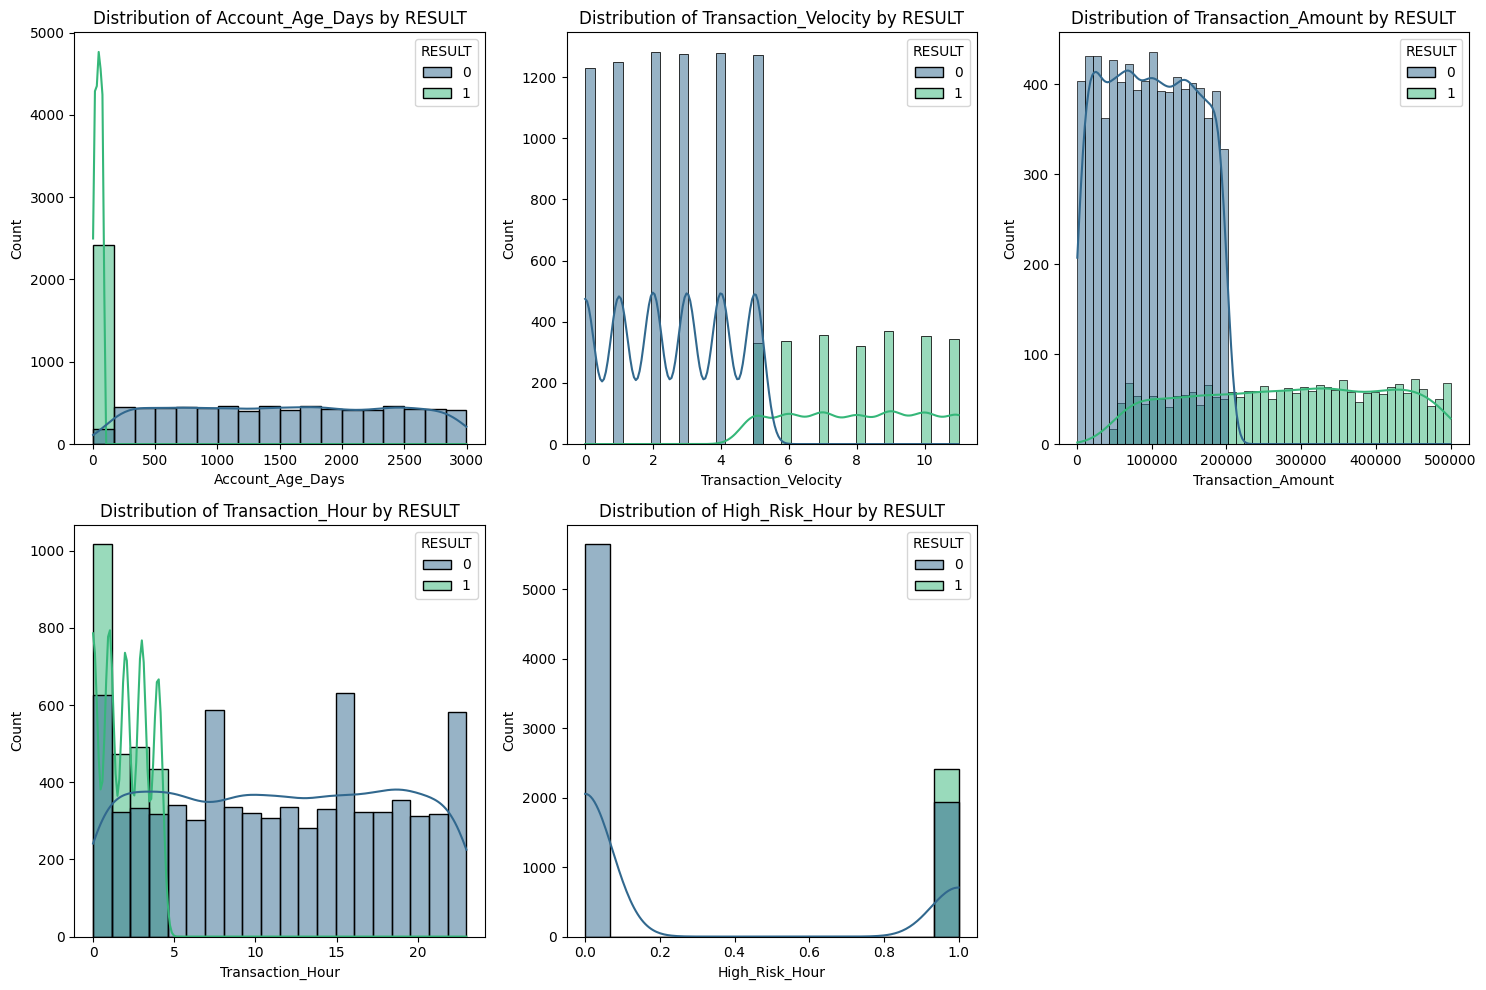

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

high_correlation_features = ['Account_Age_Days', 'Transaction_Velocity', 'Transaction_Amount', 'Transaction_Hour', 'High_Risk_Hour']

plt.figure(figsize=(15, 10))
for i, col in enumerate(high_correlation_features):
    plt.subplot(2, 3, i + 1)
    sns.histplot(data=df, x=col, hue='RESULT', kde=True, palette='viridis')
    plt.title(f'Distribution of {col} by RESULT')
plt.tight_layout()
plt.show()


In [ ]:
pip install joblib

In [ ]:
import joblib

# Save the RandomForestClassifier model
joblib.dump(rf_model, 'random_forest_fraud_model.joblib')
print("RandomForestClassifier model saved as 'random_forest_fraud_model.joblib'")

# Save the StandardScaler
joblib.dump(scaler, 'scaler.joblib')
print("StandardScaler saved as 'scaler.joblib'")

RandomForestClassifier model saved as 'random_forest_fraud_model.joblib'
StandardScaler saved as 'scaler.joblib'


In [ ]:
print("Top 8 Important Features from RandomForestClassifier:")
print(importance_df.head(8))

Top 8 Important Features from RandomForestClassifier:
                    Feature  Importance
5          Account_Age_Days    0.418954
4      Transaction_Velocity    0.226672
0        Transaction_Amount    0.147206
1          Transaction_Hour    0.111950
11           High_Risk_Hour    0.044419
3           Device_Mismatch    0.023639
7   Amount_To_Average_Ratio    0.016758
2           Location_Change    0.008431


In [ ]:
from google.colab import files

files.download('random_forest_fraud_model.joblib')
files.download('scaler.joblib')

print("Model and scaler download initiated.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Model and scaler download initiated.


In [ ]:
from google.colab import files

files.download('df_encoded.csv')

print("Encoded dataset download initiated.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Encoded dataset download initiated.


In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import joblib

# Reload the original dataset to get original string values for categorical columns
file_path = '/content/drive/MyDrive/FRAUD DETECTION PROJECT/Synthetic_Fraud_Dataset.xlsx'
df_original = pd.read_excel(file_path)

# Fill missing values in 'Device_OS' and 'Customer_Marital_Status' using their modes
for col in ['Device_OS', 'Customer_Marital_Status']:
    if df_original[col].isnull().any():
        mode_val = df_original[col].mode()[0]
        df_original[col].fillna(mode_val, inplace=True)

# Create and save LabelEncoder for 'Device_OS'
le_device_os = LabelEncoder()
le_device_os.fit(df_original['Device_OS'].astype(str)) # Fit on original string values
joblib.dump(le_device_os, 'label_encoder_Device_OS.joblib')
print("LabelEncoder for 'Device_OS' saved as 'label_encoder_Device_OS.joblib'")

# Create and save LabelEncoder for 'Customer_Marital_Status'
le_marital_status = LabelEncoder()
le_marital_status.fit(df_original['Customer_Marital_Status'].astype(str)) # Fit on original string values
joblib.dump(le_marital_status, 'label_encoder_Customer_Marital_Status.joblib')
print("LabelEncoder for 'Customer_Marital_Status' saved as 'label_encoder_Customer_Marital_Status.joblib'")

# Store the mean of 'User_Income_Estimate' for later use in Streamlit app preprocessing
user_income_estimate_mean = df_original['User_Income_Estimate'].mean()
print(f"Mean of 'User_Income_Estimate' for imputation: {user_income_estimate_mean}")

LabelEncoder for 'Device_OS' saved as 'label_encoder_Device_OS.joblib'
LabelEncoder for 'Customer_Marital_Status' saved as 'label_encoder_Customer_Marital_Status.joblib'
Mean of 'User_Income_Estimate' for imputation: 276027.06757072714


/tmp/ipykernel_1215/2550317045.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_original[col].fillna(mode_val, inplace=True)


**Reasoning**:
The subtask is to write the Streamlit application code to a file named `app.py`. I will use the `%%writefile` magic command to create this file and then paste the Streamlit code into it.



In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib

# --- 1. Load Assets ---
# Load the trained Random Forest model
rf_model = joblib.load('random_forest_fraud_model.joblib')

# Load the StandardScaler
scaler = joblib.load('scaler.joblib')

# Load individual LabelEncoders
le_device_os = joblib.load('label_encoder_Device_OS.joblib')
le_marital_status = joblib.load('label_encoder_Customer_Marital_Status.joblib')

# Get the mean for User_Income_Estimate imputation (from previous step's output)
USER_INCOME_ESTIMATE_MEAN = 276027.06757072714

# Define the feature names in the order they were trained
# (This can be obtained from X.columns used during training)
FEATURE_COLUMNS = [
    'Transaction_Amount', 'Transaction_Hour', 'Location_Change',
    'Device_Mismatch', 'Transaction_Velocity', 'Account_Age_Days',
    'AvgTransaction_Last30Days', 'Amount_To_Average_Ratio',
    'User_Income_Estimate', 'Device_OS', 'Customer_Marital_Status',
    'High_Risk_Hour'
]

# --- 2. Preprocessing Function ---
def preprocess_input(
    transaction_amount, transaction_hour, location_change, device_mismatch,
    transaction_velocity, account_age_days, avg_transaction_last30days,
    amount_to_average_ratio, user_income_estimate, device_os, customer_marital_status
):
    # Create a DataFrame from inputs
    input_data = pd.DataFrame([[
        transaction_amount, transaction_hour, location_change, device_mismatch,
        transaction_velocity, account_age_days, avg_transaction_last30days,
        amount_to_average_ratio, user_income_estimate, device_os, customer_marital_status
    ]], columns=[
        'Transaction_Amount', 'Transaction_Hour', 'Location_Change', 'Device_Mismatch',
        'Transaction_Velocity', 'Account_Age_Days', 'AvgTransaction_Last30Days',
        'Amount_To_Average_Ratio', 'User_Income_Estimate_Raw', 'Device_OS_Raw', 'Customer_Marital_Status_Raw'
    ])

    # Impute missing User_Income_Estimate
    if pd.isna(input_data['User_Income_Estimate_Raw'].iloc[0]):
        input_data['User_Income_Estimate'] = USER_INCOME_ESTIMATE_MEAN
    else:
        input_data['User_Income_Estimate'] = input_data['User_Income_Estimate_Raw']

    # Create High_Risk_Hour feature
    input_data['High_Risk_Hour'] = input_data['Transaction_Hour'].apply(lambda x: 1 if x < 6 else 0)

    # Encode categorical features
    input_data['Device_OS'] = le_device_os.transform(input_data['Device_OS_Raw'])
    input_data['Customer_Marital_Status'] = le_marital_status.transform(input_data['Customer_Marital_Status_Raw'])

    # Select and order features as per training data
    processed_df = input_data[FEATURE_COLUMNS]

    # Scale numerical features
    scaled_input = scaler.transform(processed_df)

    return scaled_input

# --- 3. Streamlit UI Layout ---
st.set_page_config(page_title='Fraud Detection App', layout='centered')

st.title('Fraud Detection Application')
st.write("Enter the transaction details below to predict if it's fraudulent or legitimate.")
st.markdown("--- ")

# List of original categorical values for select boxes
DEVICE_OS_OPTIONS = le_device_os.classes_.tolist() # e.g., ['Android', 'iOS', 'Windows']
MARITAL_STATUS_OPTIONS = le_marital_status.classes_.tolist() # e.g., ['Divorced', 'Married', 'Single', 'Widowed']

# Input fields for features
st.subheader('Transaction Details')
col1, col2 = st.columns(2)
with col1:
    transaction_amount = st.number_input('Transaction Amount', min_value=0.0, value=100000.0, step=1000.0)
    transaction_hour = st.slider('Transaction Hour (0-23)', min_value=0, max_value=23, value=12)
    transaction_velocity = st.number_input('Transaction Velocity (Transactions in last hour)', min_value=0, value=5)
    account_age_days = st.number_input('Account Age (Days)', min_value=0, value=1000)

with col2:
    location_change = st.selectbox('Location Change', options=[0, 1], format_func=lambda x: 'Yes' if x == 1 else 'No')
    device_mismatch = st.selectbox('Device Mismatch', options=[0, 1], format_func=lambda x: 'Yes' if x == 1 else 'No')
    avg_transaction_last30days = st.number_input('Average Transaction in Last 30 Days', min_value=0.0, value=50000.0, step=500.0)
    amount_to_average_ratio = st.number_input('Amount to Average Ratio', min_value=0.0, value=1.0, step=0.1, format="%.2f")

st.subheader('User Information')
col3, col4 = st.columns(2)
with col3:
    user_income_estimate = st.number_input('User Income Estimate (Optional)', min_value=0.0, value=None, placeholder="Leave blank for average")
    device_os = st.selectbox('Device OS', options=DEVICE_OS_OPTIONS)

with col4:
    customer_marital_status = st.selectbox('Customer Marital Status', options=MARITAL_STATUS_OPTIONS)

st.markdown("--- ")
st.subheader('Important Features at a Glance (From Model Analysis)')
st.write("These features were identified as most influential in predicting fraud:")
st.markdown("**1. Account Age (Days)**: Older accounts tend to be less fraudulent.")
st.markdown("**2. Transaction Velocity**: High velocity often indicates fraud.")
st.markdown("**3. Transaction Amount**: Very high or very low amounts can be suspicious.")
st.markdown("**4. Transaction Hour**: Transactions during certain hours (e.g., late night) can be riskier.")
st.markdown("**5. High Risk Hour (System Derived)**: Transactions between 00:00 and 05:59.")
st.markdown("--- ")

# Prediction Button
if st.button('Predict Fraud'):
    # Preprocess the user inputs
    processed_data = preprocess_input(
        transaction_amount, transaction_hour, location_change, device_mismatch,
        transaction_velocity, account_age_days, avg_transaction_last30days,
        amount_to_average_ratio, user_income_estimate, device_os, customer_marital_status
    )

    # Make prediction
    prediction = rf_model.predict(processed_data)
    prediction_proba = rf_model.predict_proba(processed_data)[:, 1]

    st.subheader('Prediction Result:')
    if prediction[0] == 1:
        st.error(f"\u274C Fraudulent Transaction Detected! (Probability: {prediction_proba[0]:.2f})")
        st.balloons()
    else:
        st.success(f"\u2705 Legitimate Transaction. (Probability: {prediction_proba[0]:.2f})")


st.caption("Note: This is a predictive model. Always exercise caution with suspicious transactions.")

Writing app.py


**Reasoning**:
The `app.py` file has been created. Now, I will provide the code to download the `app.py` file, along with the saved `label_encoder_Device_OS.joblib` and `label_encoder_Customer_Marital_Status.joblib` files, using `google.colab.files.download`.



In [ ]:
from google.colab import files

files.download('app.py')
files.download('label_encoder_Device_OS.joblib')
files.download('label_encoder_Customer_Marital_Status.joblib')

print("Deployment package files (app.py, label encoders) download initiated.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Deployment package files (app.py, label encoders) download initiated.


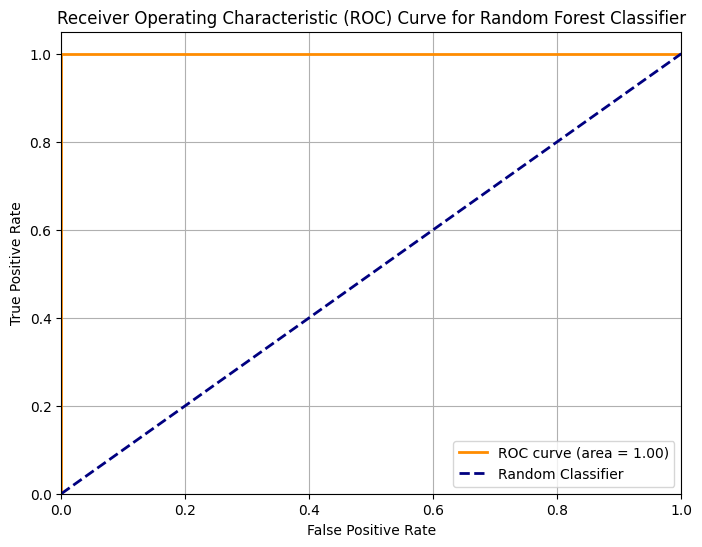

In [ ]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
import matplotlib.pyplot as plt

# Get probabilities for the positive class (fraudulent)
prob = rf_model.predict_proba(X_test_scaled)[:, 1]

# Calculate ROC curve values
fpr, tpr, thresholds = roc_curve(y_test, prob)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Random Forest Classifier')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()